**PROJETO 1**

In [15]:
import math
import pandas as pd
import numpy as np

**Variável com a planilha**

In [16]:
arquivo = 'Dados Habitacionais de Ames.xlsx'

**Datasheet da planilha**

Pra editar no python

In [17]:
df = pd.read_excel(arquivo)

**Classificação das variáveis**
- Sale Price (Preço de venda) - quantitativo contínuo
- Lot area (Área do lote) - quantitativo contínuo
- neighborhood (bairro) - qualitativo nominal

**Contexto**

Nós somos uma corretora de imoveis, afim de melhorar a eficiência do nosso trabalho e providenciar um serviço mais preciso, utilizando o nosso banco de dados  uma pesquisa de mercado para categorizar os nossos imoveis em preço, área do lote e Bairro, para obter as melhores tendências do mercado imobiliario.

**BAIRRO**

Listando todos os bairros e sua frequência absoluta

In [18]:
df1 = df.Neighborhood.value_counts()
df1

Neighborhood
NAmes      443
CollgCr    267
OldTown    239
Edwards    194
Somerst    182
NridgHt    166
Gilbert    165
Sawyer     151
NWAmes     131
SawyerW    125
Mitchel    114
BrkSide    108
Crawfor    103
IDOTRR      93
Timber      72
NoRidge     71
StoneBr     51
SWISU       48
ClearCr     44
MeadowV     37
BrDale      30
Blmngtn     28
Veenker     24
NPkVill     23
Blueste     10
Greens       8
GrnHill      2
Landmrk      1
Name: count, dtype: int64

**CONVERTER DADOS PARA DATAFRAME**

In [19]:
dadosvquali = pd.DataFrame(df1)
dadosvquali = dadosvquali.rename(columns={'count': 'Frequência absoluta'})
dadosvquali

,Frequência absoluta
Neighborhood,
NAmes,443
CollgCr,267
OldTown,239
Edwards,194
Somerst,182
NridgHt,166
Gilbert,165
Sawyer,151
NWAmes,131


**TOTAL DOS DADOS**

Temos 2930 linhas

In [20]:
Totalcasas = df1.sum()
Totalcasas

np.int64(2930)

**FREQUÊNCIA RELATIVA USANDO O TOTAL DE CASAS**

In [21]:
dadosvquali["Frequência %"]=round(dadosvquali['Frequência absoluta']*100/Totalcasas,2)
dadosvquali

,Frequência absoluta,Frequência %
Neighborhood,,
NAmes,443,15.12
CollgCr,267,9.11
OldTown,239,8.16
Edwards,194,6.62
Somerst,182,6.21
NridgHt,166,5.67
Gilbert,165,5.63
Sawyer,151,5.15
NWAmes,131,4.47


**Montando tabela de frequência Acumulada e Acumulada (%)**

In [22]:
freqacum=np.cumsum(dadosvquali.sort_index())
freqacum

,Frequência absoluta,Frequência %
Neighborhood,,
Blmngtn,28,0.96
Blueste,38,1.30
BrDale,68,2.32
BrkSide,176,6.01
ClearCr,220,7.51
CollgCr,487,16.62
Crawfor,590,20.14
Edwards,784,26.76
Gilbert,949,32.39


**Gerando a Tabela completa**

In [23]:
coluna = 'Neighborhood'
dist_freq = pd.DataFrame({
    'Frequência': dadosvquali['Frequência absoluta'],
    'Frequência Relativa (%)': dadosvquali['Frequência %'],
    'Freq.Acum.': freqacum['Frequência absoluta'],
    'Freq.Rel.Acum. (%)': freqacum['Frequência %']
})
dist_freq = round(dist_freq, 2)
print(dist_freq)
print(f'\n      Variável:{coluna}')
print('     *Limites superiores do intervalo de classes não incluídos')

              Frequência  Frequência Relativa (%)  Freq.Acum.  \
Neighborhood                                                    
Blmngtn               28                     0.96          28   
Blueste               10                     0.34          38   
BrDale                30                     1.02          68   
BrkSide              108                     3.69         176   
ClearCr               44                     1.50         220   
CollgCr              267                     9.11         487   
Crawfor              103                     3.52         590   
Edwards              194                     6.62         784   
Gilbert              165                     5.63         949   
Greens                 8                     0.27         957   
GrnHill                2                     0.07         959   
IDOTRR                93                     3.17        1052   
Landmrk                1                     0.03        1053   
MeadowV               37 

**GERANDO GRÁFICOS**

gerando gráficos com a base de dados

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

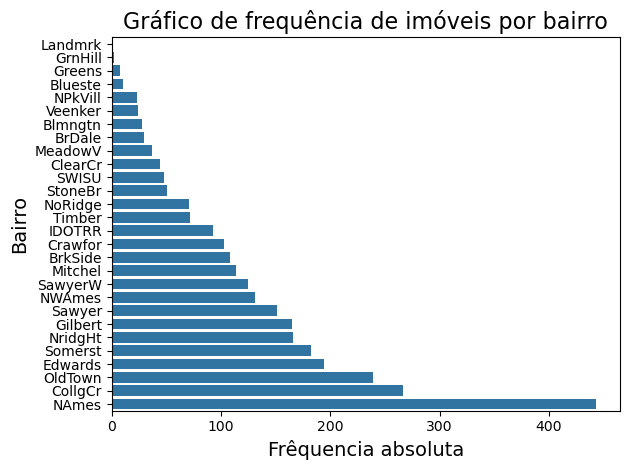

In [25]:
neighborhood_ordem = df['Neighborhood'].value_counts().sort_values(ascending=True).index
sns.countplot(y='Neighborhood', data=df, order=neighborhood_ordem)
plt.title('Gráfico de frequência de imóveis por bairro',size=16)
plt.xlabel('Frêquencia absoluta',size=14)
plt.ylabel('Bairro',size=14)
plt.tight_layout()
plt.show()

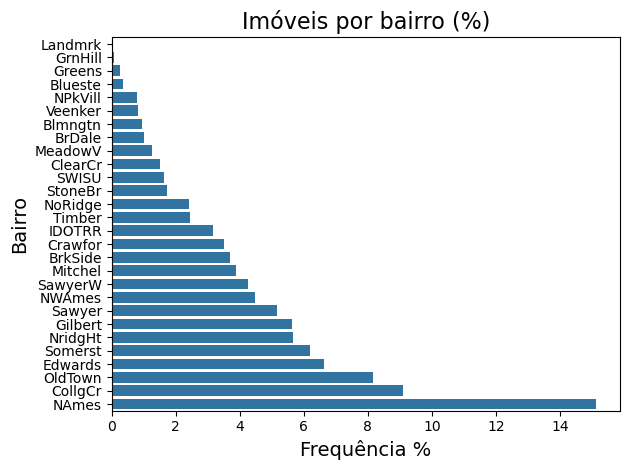

In [26]:
dados = dadosvquali.sort_values('Frequência %')

sns.barplot(x='Frequência %', y=dados.index, data=dados)

plt.title('Imóveis por bairro (%)',size=16)
plt.xlabel('Frequência %',size=14)
plt.ylabel('Bairro',size=14)

plt.tight_layout()
plt.show()

**MODA DE CASAS POR BAIRRO**

In [32]:
print('Moda:', df1.idxmax(), '| Frequência: ',df1.max())

Moda: NAmes | Frequência:  443
